In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("../data/data.csv")

In [4]:
df_train = df.sample(frac=0.8, random_state=42)
df_val = df.drop(df_train.index)

In [5]:
print(df_train.shape, df_val.shape, df.shape)

(8709, 17) (2177, 17) (10886, 17)


In [6]:
df_train.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000,8709.000000
mean,8522.045470,2.507176,0.499828,6.526352,11.572167,0.027213,3.002067,0.683316,1.419796,0.493150,0.472803,0.619308,0.190751,35.820530,155.936617,191.757148
std,5031.105883,1.115453,0.500029,3.444074,6.897437,0.162714,2.005675,0.465210,0.638062,0.190524,0.169997,0.192561,0.122033,49.519075,151.448724,181.465385
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.015200,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4257.000000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.470000,0.104500,4.000000,38.000000,44.000000
50%,8358.000000,3.000000,0.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.620000,0.194000,17.000000,119.000000,145.000000
75%,13022.000000,4.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.640000,0.621200,0.780000,0.253700,48.000000,222.000000,283.000000
max,17093.000000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,3.000000,0.960000,0.909100,1.000000,0.850700,367.000000,886.000000,977.000000


In [7]:
df_train

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
3133,4694,2011-07-19,3,0,7,11,0,2,1,1,0.82,0.8030,0.59,0.0000,29,98,127
5786,9010,2012-01-16,1,1,1,6,1,1,0,1,0.10,0.1364,0.54,0.0896,0,13,13
5224,8163,2011-12-11,4,0,12,18,0,0,0,1,0.24,0.2273,0.48,0.1940,12,151,163
8953,14094,2012-08-15,3,1,8,10,0,3,1,2,0.72,0.6818,0.62,0.1940,70,163,233
8054,12643,2012-06-15,2,1,6,23,0,5,1,1,0.62,0.6212,0.53,0.2537,46,176,222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5946,9458,2012-02-03,1,1,2,23,0,5,1,1,0.26,0.2727,0.70,0.1045,3,74,77
4583,7259,2011-11-04,4,0,11,1,0,5,1,2,0.40,0.4091,0.82,0.0000,1,16,17
5784,9008,2012-01-16,1,1,1,4,1,1,0,1,0.12,0.1515,0.58,0.1045,2,6,8
7569,11870,2012-05-14,2,1,5,18,0,1,1,2,0.58,0.5455,0.83,0.0000,17,283,300


In [8]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 8709 entries, 3133 to 521
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     8709 non-null   int64  
 1   dteday      8709 non-null   str    
 2   season      8709 non-null   int64  
 3   yr          8709 non-null   int64  
 4   mnth        8709 non-null   int64  
 5   hr          8709 non-null   int64  
 6   holiday     8709 non-null   int64  
 7   weekday     8709 non-null   int64  
 8   workingday  8709 non-null   int64  
 9   weathersit  8709 non-null   int64  
 10  temp        8709 non-null   float64
 11  atemp       8709 non-null   float64
 12  hum         8709 non-null   float64
 13  windspeed   8709 non-null   float64
 14  casual      8709 non-null   int64  
 15  registered  8709 non-null   int64  
 16  cnt         8709 non-null   int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 1.2 MB


In [9]:
df_train.isna().sum(axis=0)

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
print("Discret values")
for col in df_train.columns:
    value_counts = df_train[col].value_counts()
    if len(value_counts) <= 10:
        print(value_counts)

Discret values
season
2    2192
3    2188
4    2186
1    2143
Name: count, dtype: int64
yr
0    4356
1    4353
Name: count, dtype: int64
holiday
0    8472
1     237
Name: count, dtype: int64
weekday
6    1264
0    1257
4    1246
2    1243
3    1236
1    1233
5    1230
Name: count, dtype: int64
workingday
1    5951
0    2758
Name: count, dtype: int64
weathersit
1    5765
2    2232
3     712
Name: count, dtype: int64


In [11]:
df_train.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

<Axes: >

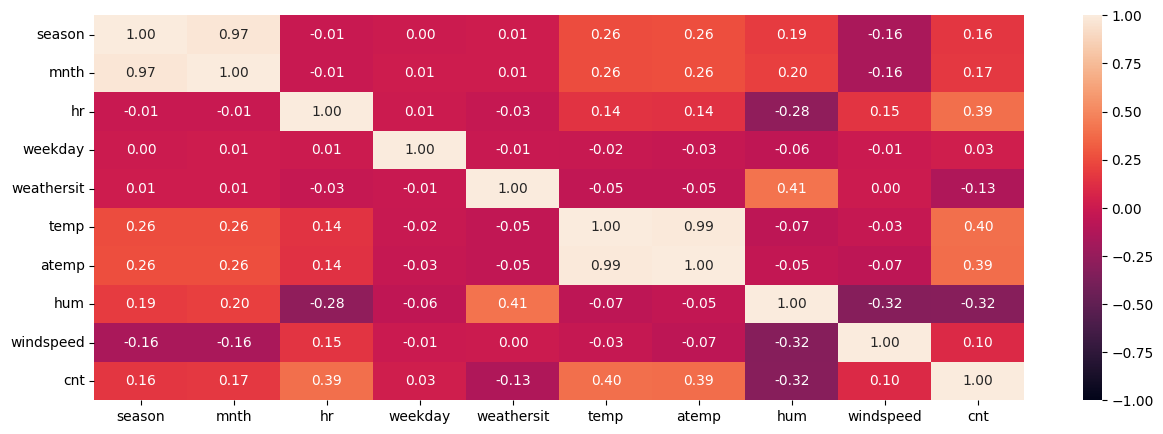

In [12]:
corr = df_train.drop(columns=["instant", "dteday", "yr", "workingday", "holiday", "registered", "casual"]).corr()
plt.figure(figsize=(15, 5))
sns.heatmap(corr, vmin=-1, vmax=1, annot=True, fmt=".2f")

In [13]:
df_train_dropped = df_train.drop(columns=["instant", "dteday", "registered", "casual", "atemp"])

In [18]:
weekday_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
weathersit_mapping = {
    1: "sunny",
    2: "windy",
    3: "rainy"
}

df["weekday"] = df["weekday"].map(weekday_mapping)
df["weathersit"] = df["weathersit"].map(weekday_mapping)

In [19]:
df_train_dummies = pd.get_dummies(df_train_dropped, prefix="is", columns=['weathersit', 'weekday'], dtype=int)

In [23]:
continous_cols = list(df_train_dummies.select_dtypes(["float"]).columns)
print(continous_cols)

['temp', 'hum', 'windspeed']


In [28]:
df_continous = df_train_dummies[continous_cols]
df_continous

,temp,hum,windspeed
3133,0.82,0.59,0.0000
5786,0.10,0.54,0.0896
5224,0.24,0.48,0.1940
8953,0.72,0.62,0.1940
8054,0.62,0.53,0.2537
...,...,...,...
5946,0.26,0.70,0.1045
4583,0.40,0.82,0.0000
5784,0.12,0.58,0.1045
7569,0.58,0.83,0.0000


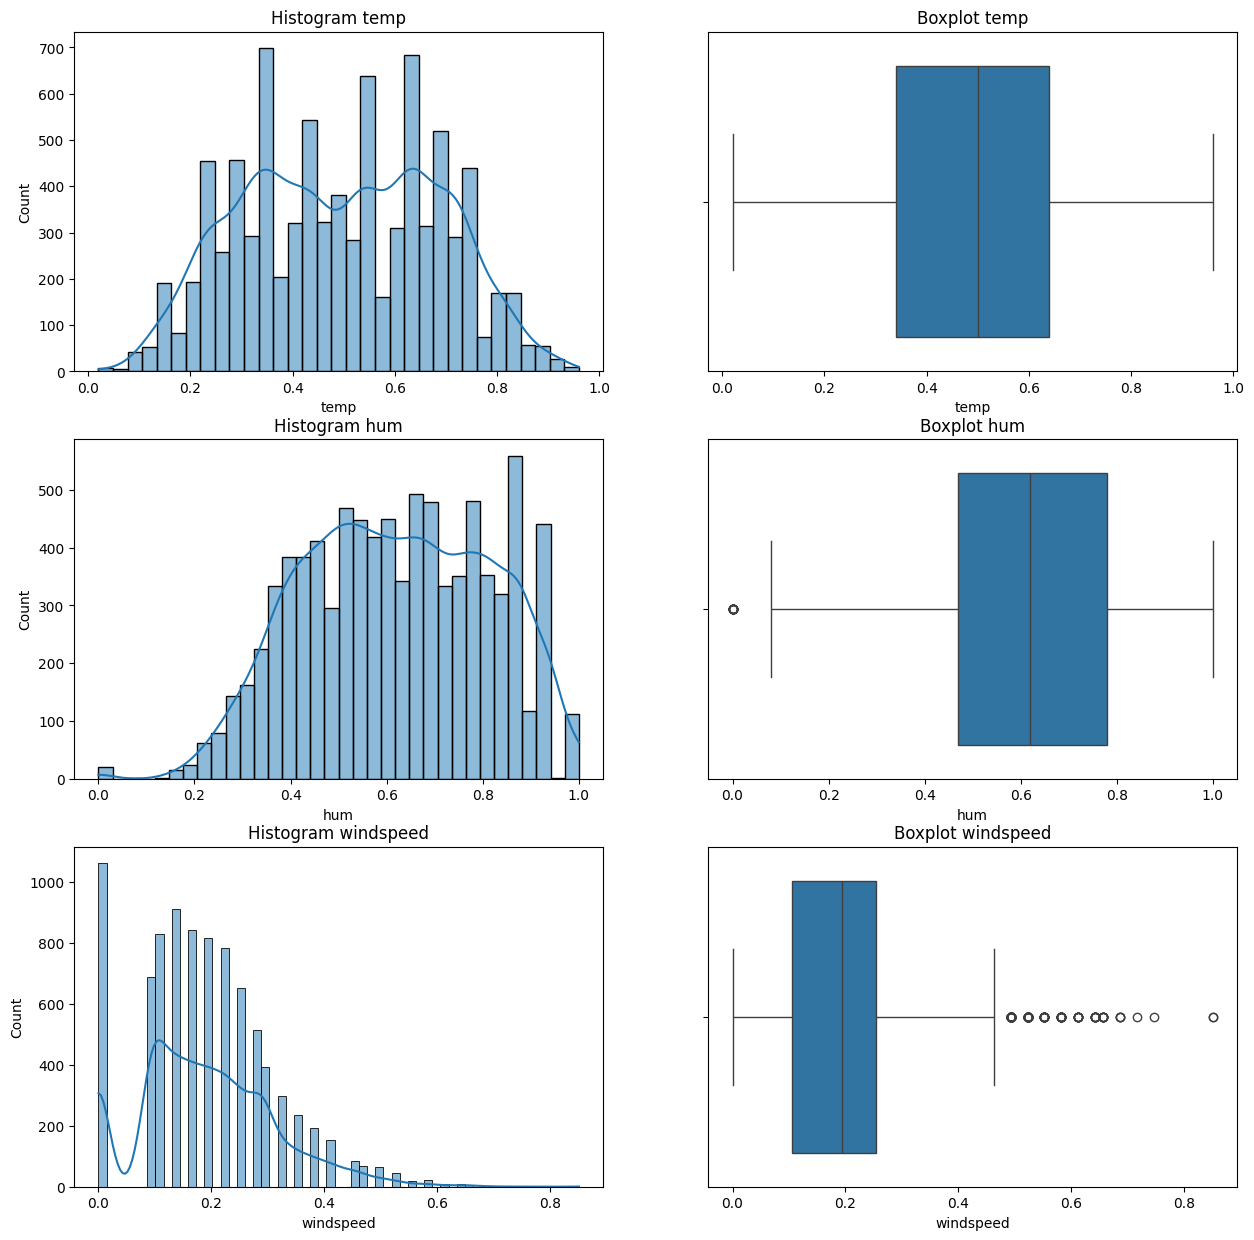

In [37]:
fig, axes = plt.subplots(len(continous_cols), 2, figsize=(15, 15))

for i, col in enumerate(continous_cols):
    sns.histplot(df_continous, x=col, ax=axes[i, 0], kde=True)
    axes[i, 0].set_title(f"Histogram {col}")
    sns.boxplot(df_continous, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot {col}")

plt.show()

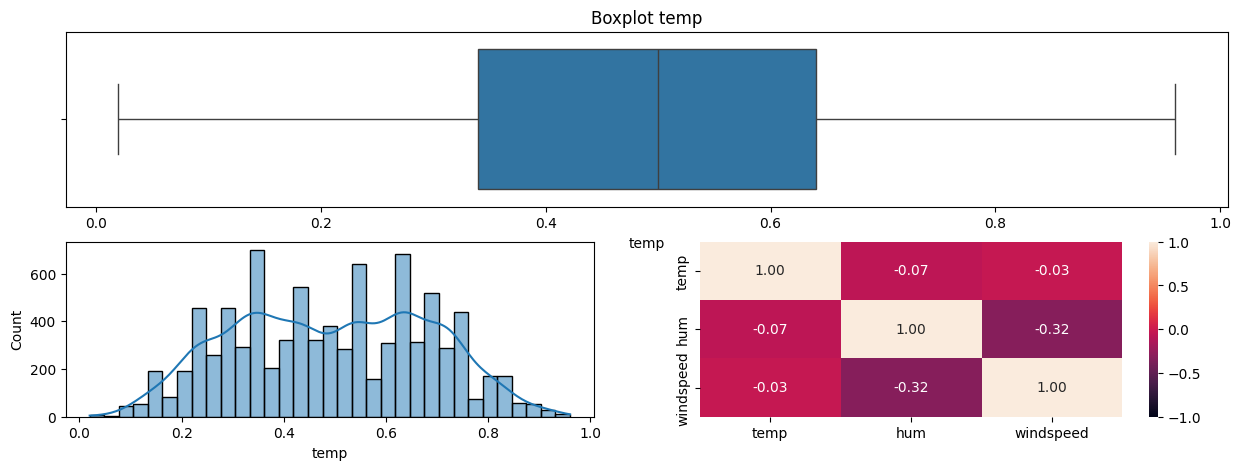

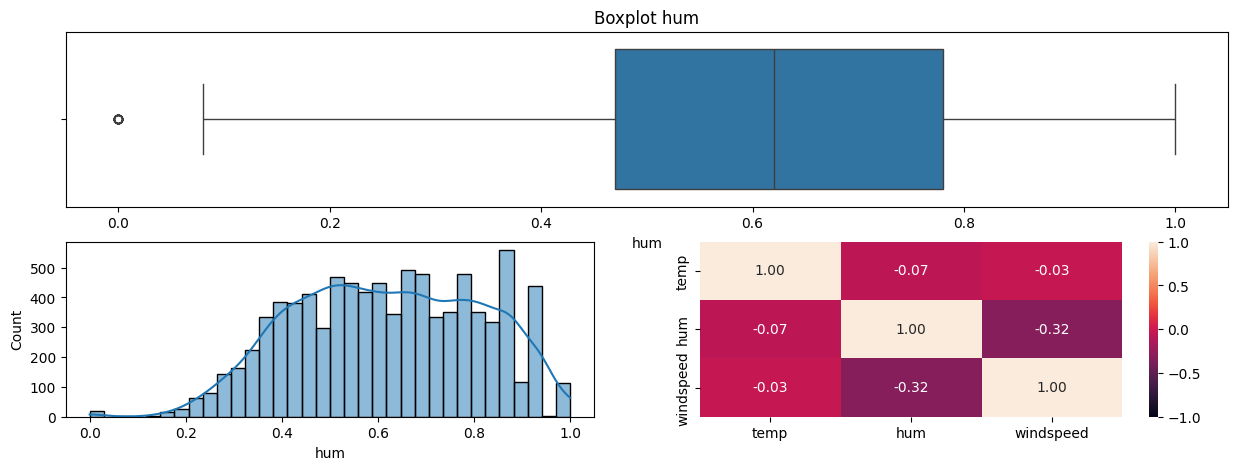

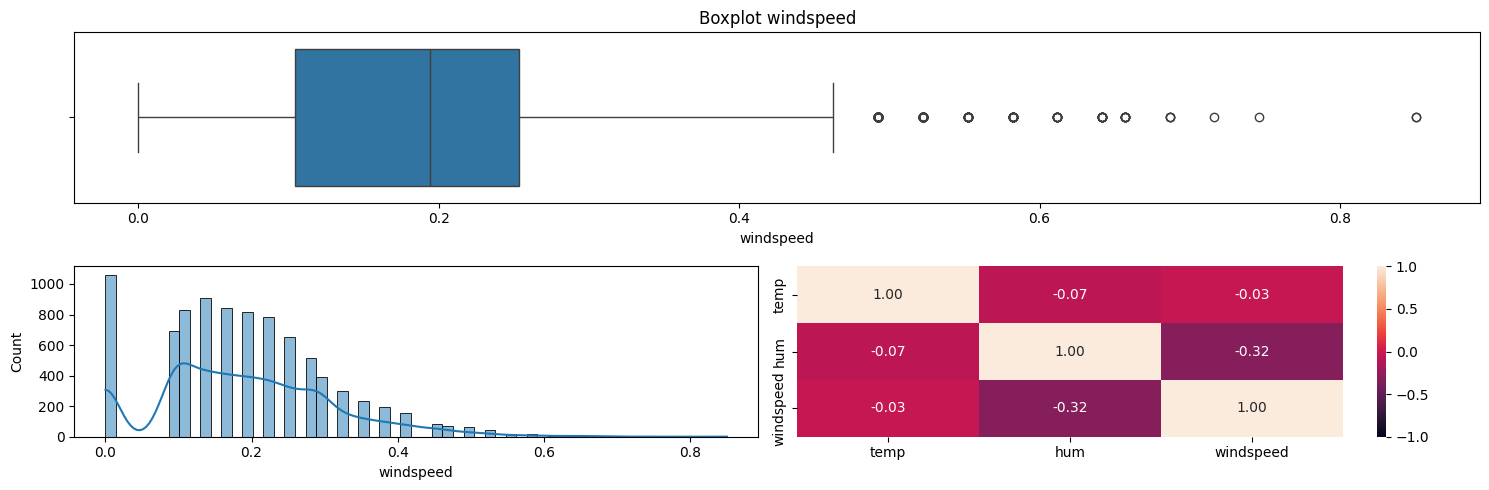

In [40]:
corr = df_continous.corr()

for col in continous_cols:
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(2, 2)

    ax_top = fig.add_subplot(gs[0, :])
    ax_top.set_title(f"Boxplot {col}")
    sns.boxplot(df_continous, x=col, ax=ax_top)

    ax_bot1 = fig.add_subplot(gs[1, 0])
    sns.histplot(df_continous, x=col, ax=ax_bot1, kde=True)

    ax_bot2 = fig.add_subplot(gs[1, 1])
    sns.heatmap(corr, vmin=-1, vmax=1, fmt=".2f", annot=True)

plt.tight_layout()
plt.show()